In [1]:
%pylab inline
import astropy.units as u
from astropy.cosmology import Planck15
import matplotlib.colors as colors
from scipy.optimize import curve_fit
import scipy.integrate as integrate
import numpy.random
from numpy.linalg import det
from mpl_toolkits import mplot3d
import matplotlib.ticker as ticker

plt.rc('font', family='serif')
mpl.rcParams['ytick.labelsize'] = 24
mpl.rcParams['xtick.labelsize'] = 24
mpl.rcParams['axes.labelsize'] = 34
mpl.rcParams['legend.fontsize'] = 24
def fmt(x, pos):
    a, b = '{:.1e}'.format(x).split('e')
    b = int(b)
    return r'${}\!\times 10^{{{}}}$'.format(a, b)

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import healpy as hp

import sys, platform, os
import camb
from camb import model, initialpower


import warnings
warnings.filterwarnings('ignore')


Populating the interactive namespace from numpy and matplotlib


In [2]:
#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()
#This function sets up CosmoMC-like settings, with one massive neutrino and helium set using BBN consistency
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)
pars.set_for_lmax(2500, lens_potential_accuracy=0);

results = camb.get_results(pars)
powers =results.get_cmb_power_spectra(pars, CMB_unit='muK')
totCL_fiducial=powers['total']
ls = np.arange(totCL_fiducial.shape[0])

In [3]:

def plotCMB(cmbMap):
    fig = plt.figure(figsize=(16,16))
    ax = fig.add_subplot(111)

    #plotting map
    im = ax.imshow(cmbMap,vmin=-0.0005, vmax=0.0005)
    
    #setting position and size of colorbar (xPos,yPos,width,height)
    cax = fig.add_axes([0.32, 0.25, 0.4, 0.018]) 
    cbar = fig.colorbar(im,orientation="horizontal",cax=cax)
    cbar.set_label('$\Delta T$', size=24, labelpad=20)
    ax.axis('off')

def createCldata (oBar):
    pars = camb.CAMBparams()
    #This function sets up CosmoMC-like settings, with one massive neutrino and helium set using BBN consistency
    pars.set_cosmology(H0=67.5, ombh2=oBar, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
    pars.InitPower.set_params(As=2e-9, ns=0.965, r=0)
    pars.set_for_lmax(2500, lens_potential_accuracy=0);

    results = camb.get_results(pars)
    powers =results.get_cmb_power_spectra(pars, CMB_unit='muK')
    totCL_new=powers['total']
    ls = np.arange(totCL.shape[0])    

    np.savetxt("ClSpectra/Cl_%.3f.dat"%oBar,(ls,totCL_new[:,0]))

def plotCMBps (oBar):
    
    ls,clCur = np.loadtxt("ClSpectra/Cl_%.3f.dat"%oBar)

    #print(clCur)
    
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)

    startI = 10
    ax.plot(ls[startI:],totCL_fiducial[startI:], color='k')
    ax.plot(ls[startI:],clCur[startI:], color='#2966a3')
    ax.set_xlim([0,2500])
    ax.set_ylim([0,15000])
    barPercent = oBar*100
    ax.text(1750,13000,"Atome: %.1f%%"%barPercent,size=28,color='#2966a3')
    ax.text(1750,11800,"Atome: 2.2%",size=28,color='k')
    
    synCMB = hp.synfast(clCur,nside=512)
    mollview = hp.mollview(synCMB,return_projected_map=True)[::-1];
    #plt.close("all")

    #plotCMB(mollview)


    
def checkData(minObar,maxObar,stepSize):
    oBar = minObar
    while oBar < maxObar:
        fileExists = os.path.isfile("ClSpectra/Cl_%.3f.dat"%oBar)
        if(not fileExists):
            createCldata(oBar)
        oBar += stepSize
        
        

In [4]:
# set parameters fro slider widget        
minObar = 0.002
maxObar = 0.2
stepSize = 0.01

#check if all necessary files are available
#create them if necessary
checkData(minObar,maxObar,stepSize)

#loadFiducial data
ls,totCL_fiducial = np.loadtxt("ClSpectra/Cl_0.022.dat")


In [5]:
int_wdgt = widgets.FloatSlider(
    description=r'$\ell_\text{max}$:',
    fontsize=34,
    value=minObar,
    min=minObar, max=maxObar, step=stepSize,
    layout=widgets.Layout(width='90%'))

widgets.interact(plotCMBps, oBar=int_wdgt)


interactive(children=(FloatSlider(value=0.002, description='$\\ell_\\text{max}$:', layout=Layout(width='90%'),…

<function __main__.plotCMBps(oBar)>

In [6]:
oBar = 0.022 
ls,clCur = np.loadtxt("ClSpectra/Cl_%.3f.dat"%oBar)

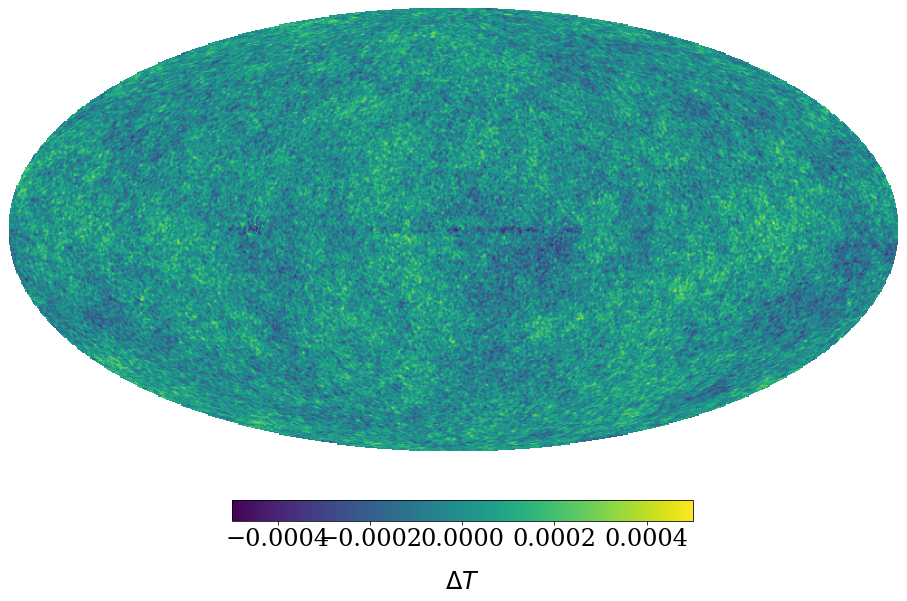

In [7]:
cmbMap = hp.read_map("planckSmica512.fits")
nside = hp.pixelfunc.get_nside(cmbMap)

if (nside!=512):
    raise NameError('Code only implemented for nsideCMB = nsideEart = 512')

mollview = hp.mollview(cmbMap,return_projected_map=True)[::-1];
hp.graticule()
plt.close("all")

plotCMB(mollview)

clCMB = hp.anafast(cmbMap)


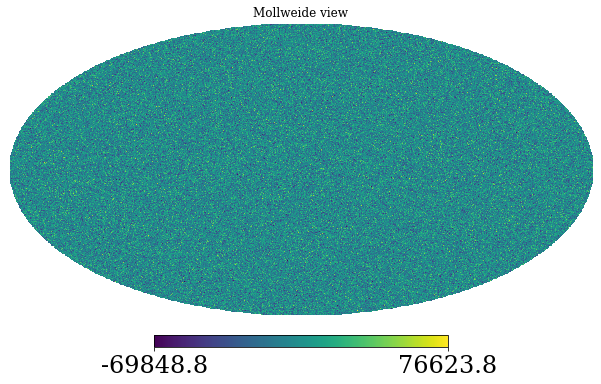

In [8]:
synCMB = hp.synfast(clCur,nside=512)
mollview = hp.mollview(synCMB,return_projected_map=True)[::-1];

Text(1750, 11800, 'Atome: 2.2%')

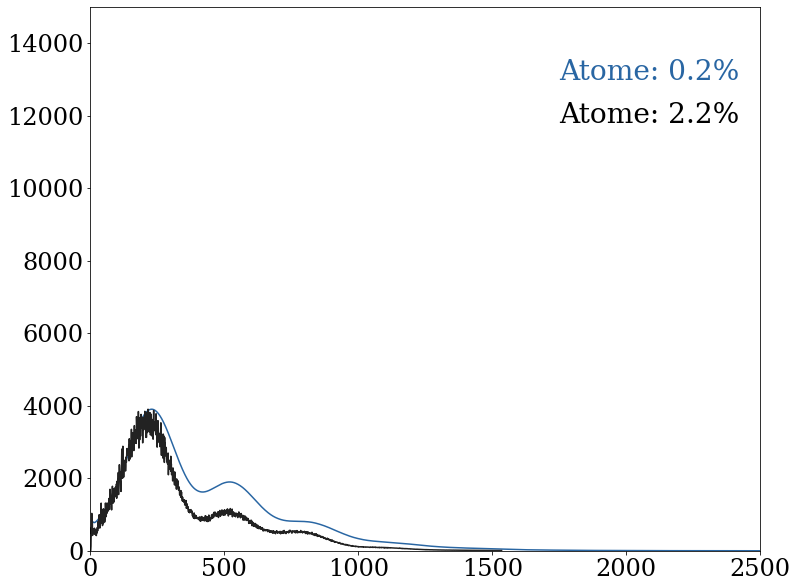

In [27]:
oBar = 0.002

ls,clCur = np.loadtxt("ClSpectra/Cl_%.3f.dat"%oBar)

clCMBdimLess = ellCMB*(1+ellCMB)*clCMB

clCMBdimLess = clCMBdimLess/max(clCMBdimLess)*max(clCur[startI:])
clCMB = clCMB/max(clCMB)*max(clCur[startI:])

#print(clCur)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111)

startI = 10
#ax.plot(ls[startI:],totCL_fiducial[startI:], color='k')
ax.plot(ls[startI:],clCur[startI:], color='#2966a3')
ax.plot(ellCMB, clCMBdimLess, c="#222222", lw=1.5)

ax.set_xlim([0,2500])
ax.set_ylim([0,15000])
barPercent = oBar*100
ax.text(1750,13000,"Atome: %.1f%%"%barPercent,size=28,color='#2966a3')
ax.text(1750,11800,"Atome: 2.2%",size=28,color='k')

#synCMB = hp.synfast(clCur,nside=512)


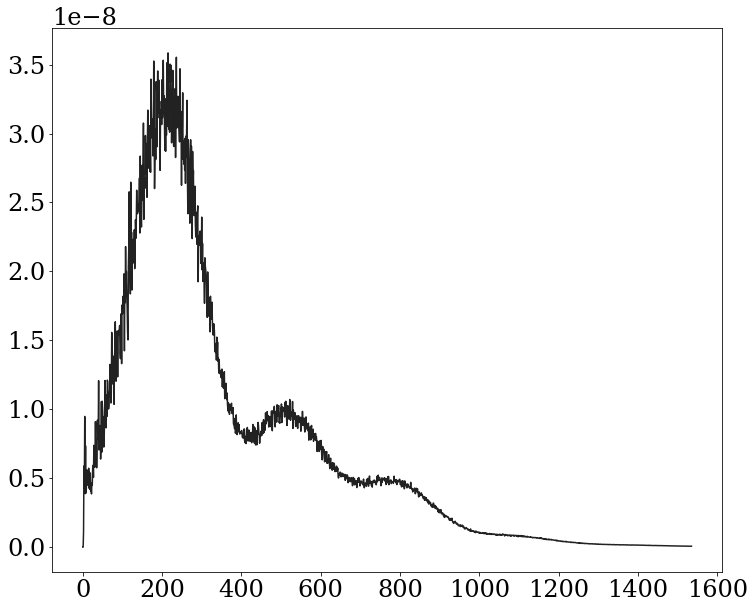

In [32]:
def plotSynteticCMB (oBar):
    
    ls,clCur = np.loadtxt("ClSpectra/Cl_%.3f.dat"%oBar)
    startI = 10

    synteticCMBspec = clCur[startI:]/ls[startI:]/(ls[startI:]+1)
    synteticCMBspec = synteticCMBspec/max(synteticCMBspec)*max(clCMB)

    synCMB = hp.synfast(synteticCMBspec,nside=512)
    mollview = hp.mollview(synCMB,return_projected_map=True)[::-1];


In [33]:



int_wdgt = widgets.FloatSlider(
    description=r'$\ell_\text{max}$:',
    fontsize=34,
    value=minObar,
    min=minObar, max=maxObar, step=stepSize,
    layout=widgets.Layout(width='90%'))

widgets.interact(plotSynteticCMB, oBar=int_wdgt)


interactive(children=(FloatSlider(value=0.002, description='$\\ell_\\text{max}$:', layout=Layout(width='90%'),…

<function __main__.plotSynteticCMB(oBar)>

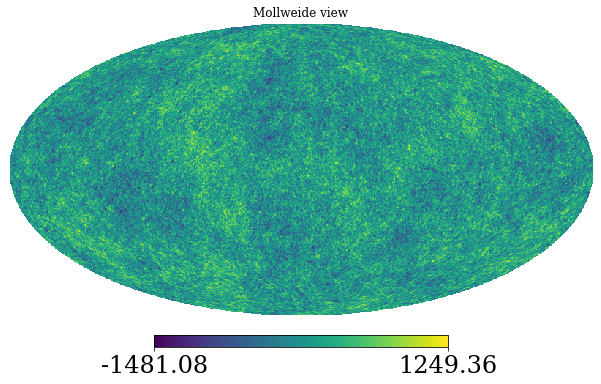

In [29]:
synCMB = hp.synfast(clCMB,nside=512)
mollview = hp.mollview(synCMB,return_projected_map=True)[::-1];

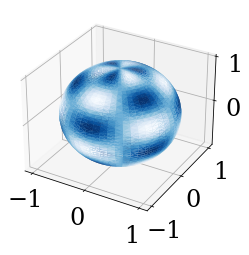

In [33]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

(n, m) = (50, 50)

# Meshing a unit sphere according to n, m 
theta = np.linspace(0, 2 * np.pi, num=n, endpoint=False)
phi = np.linspace(np.pi * (-0.5 + 1./(m+1)), np.pi*0.5, num=m, endpoint=False)
theta, phi = np.meshgrid(theta, phi)
theta, phi = theta.ravel(), phi.ravel()
theta = np.append(theta, [0.]) # Adding the north pole...
phi = np.append(phi, [np.pi*0.5])



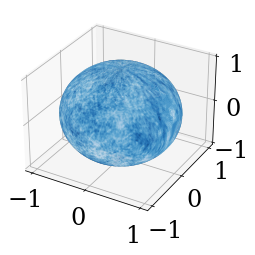

In [94]:

cmbMap = hp.read_map("planckSmica512.fits")
nsideNew = 64 #hp.pixelfunc.get_nside(cmbMap)
mapLowRes = hp.ud_grade(cmbMap,nsideNew)
npix = hp.nside2npix(nsideNew) 
theta,phi = hp.pix2ang(nsideNew,np.arange(npix))

mesh_x, mesh_y = ((np.pi*0.5 - phi)*np.cos(theta), (np.pi*0.5 - phi)*np.sin(theta))
triangles = mtri.Triangulation(mesh_x, mesh_y).triangles
x, y, z = np.cos(phi)*np.cos(theta), np.cos(phi)*np.sin(theta), np.sin(phi)
#x, y, z = hp.pix2vec(nside,np.arange(nside**3))



# Defining a custom color scalar field
vals = mapLowRes
colors = np.mean(vals[triangles], axis=1)



In [ ]:

src = mlab.pipeline.array2d_source(im)
warp = mlab.pipeline.warp_scalar(src)
normals = mlab.pipeline.poly_data_normals(warp)
surf = mlab.pipeline.surface(normals)
mlab.show()

In [2]:
from mayavi import mlab

# Plotting
fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d')
cmap = plt.get_cmap('viridis')
triang = mtri.Triangulation(x, y, triangles)
collec = ax.plot_trisurf(triang, z, cmap=cmap, shade=False, linewidth=0.)
collec.set_array(colors)
collec.autoscale()
plt.show()


ModuleNotFoundError: No module named 'mayavi'

In [100]:
from mayavi import mlab

X, Y = np.meshgrid(np.arange(128), np.arange(128))
Z = np.zeros_like(X)
im = np.sin(X/10 + Y/100)

#fig = plt.figure()
#x = fig.add_subplot(111, projection='3d')

src = mlab.pipeline.array2d_source(im)
warp = mlab.pipeline.warp_scalar(src)
normals = mlab.pipeline.poly_data_normals(warp)
surf = mlab.pipeline.surface(normals)
mlab.show()

ModuleNotFoundError: No module named 'mayavi'

In [3]:
from mayavi import mlab


ModuleNotFoundError: No module named 'mayavi'